In [201]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

## Proposed Model
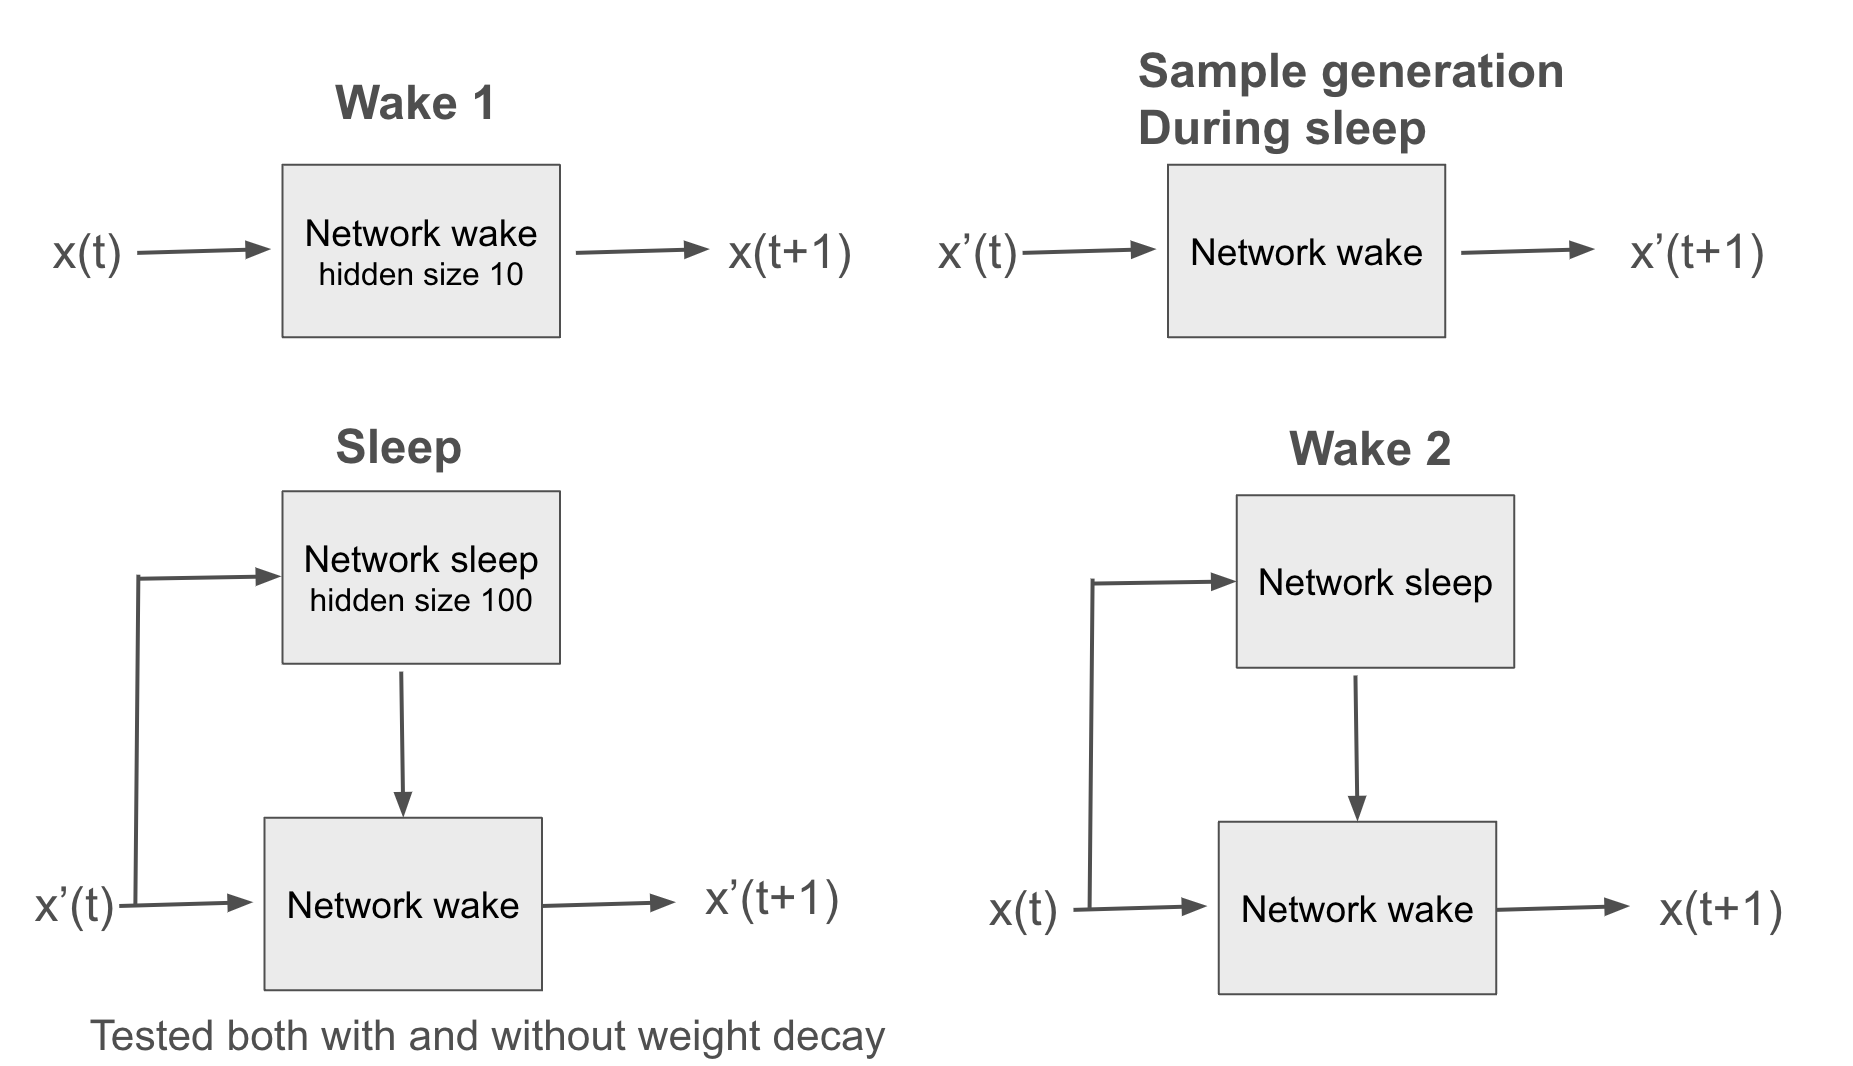

In [202]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [203]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size_hippocampus, hidden_size_cortex, num_layers_hippocampus=1, num_layers_cortex=1, memory_buffer=10):
        super(RNN, self).__init__()
        self.cortex_hidden = torch.zeros(1, 1, hidden_size_cortex)
        
        self.hidden_size_cortex = hidden_size_cortex
        self.hidden_size_hippocampus = hidden_size_hippocampus
        self.rnn_hippocampus = nn.RNN(input_size+hidden_size_cortex, hidden_size_hippocampus, num_layers_hippocampus, batch_first=True)
        self.rnn_cortex = nn.RNN(input_size, hidden_size_cortex, num_layers_cortex, batch_first=True)
        
        self.fc = nn.Linear(hidden_size_hippocampus, len(tokens))
        
    def forward(self, x, h0=None, hc=None, sleep=False):
        if sleep:
            if hc == None:
                cortex_out, hc = self.rnn_cortex(x)
            else:
                cortex_out, hc = self.rnn_cortex(x, hc)
            
            x = torch.cat((x,cortex_out), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        else:
            x = torch.cat((x,self.cortex_hidden), dim=2)
                
            if h0 == None:
                out, h0 = self.rnn_hippocampus(x)
            else:   
                out, h0 = self.rnn_hippocampus(x, h0)
    
            out = self.fc(out)
        
        
 
        # else:
        #     x = torch.cat((x,self.cortex_hidden), dim=2)
        #     if h0 == None:
        #         out, h0 = self.rnn_hippocampus(x)
        #     else:   
        #         out, h0 = self.rnn_hippocampus(x, h0)
            
        if sleep:
            return out[:,-1,:], h0, hc

        return out[:,-1,:], h0

In [204]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [205]:
def generate_sleep_samples(main_model, n_samples):
    seq = ''
    idx = torch.randint(0, len(tokens), (1,)) [0]
    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    
    for ii in range(n_samples+50):
        if ii == 0:
            # seq += tokens[idx]        
            X_hat, mem = main_model(X_hat.reshape(1,1,-1))
        else:
            X_hat, mem = main_model(X_hat, mem)
    
        # mem = mem + 1e-1*torch.rand(mem.shape)
        # X_hat = torch.tensor(X_hat, requires_grad=False)
        X_hat = torch.nn.functional.softmax(X_hat, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()
    
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)   
    
        if ii>50:
            seq += tokens[idx]

    return seq

In [207]:
### initial training ###
total_samples = 120000
initial_training_sample = 20000
sleep_samples = 20000
working_memory = 1
short_term_memory = 1
hidden_size_hippocampus = 20
hidden_size_cortex = 20
num_layers = 1
lr = 5e-4
lambda_reg = 1e-14
reps = 5
test_acc = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    data_test = get_sequence(total_samples+sleep_samples, 2, 3, train=False, random_state=rep)
    data_set = Dataset_converter(data[:initial_training_sample], working_memory, short_term_memory)
    data_set_test = Dataset_converter(data_test[:initial_training_sample], working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, num_layers)
    main_model.rnn_cortex.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward(retain_graph=True)
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()

            if total == 0:
                predicted_y, hidden_ = main_model(X_test)
            else:
                predicted_y, hidden_ = main_model(X_test, hidden_)

            
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to sleep ...')
    data_sleep = generate_sleep_samples(main_model, sleep_samples)#get_sequence(sleep_samples, 2, 3, random_state=rep)#
    main_model.rnn_cortex.requires_grad = True
    data_set = Dataset_converter(data_sleep, working_memory, short_term_memory)
    sleep_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    # optimizer = torch.optim.Adam([
    #                                 {'params': main_model.rnn_hippocampus.parameters(), 'weight_decay': 1e-8},  # Apply weight decay to hippocampus
    #                                 {'params': main_model.rnn_cortex.parameters()},  # No weight decay for cortex
    #                                 {'params': main_model.fc.parameters()},
    #                             ], lr=lr)
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr)
    
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for X, y in sleep_loader:
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)

        
        loss = criterion(predicted_y, y)
        l1_norm = sum(p.abs().sum() for p in main_model.rnn_hippocampus.parameters())
        loss += lambda_reg * l1_norm
        
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()
            
            true_y = y.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


    print('Going to awake phase ...')
    # data_sleep = generate_sleep_samples(main_model, sleep_samples)
    main_model.rnn_cortex.requires_grad = False
    data_set = Dataset_converter(data[initial_training_sample:], working_memory, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 

    data_set = Dataset_converter(data_test[initial_training_sample:], working_memory, short_term_memory)
    test_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    sleep_iter = 0
    
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if sleep_iter == 0:
            predicted_y, hidden, hidden_sleep = main_model(X, sleep=True)
        else:
            predicted_y, hidden, hidden_sleep = main_model(X, mem, mem_, sleep=True)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()
            mem_ = hidden_sleep.clone()

            if sleep_iter == 0:
                predicted_y, hidden_, hidden_sleep_ = main_model(X_test, sleep=True)
            else:
                predicted_y, hidden_, hidden_sleep_ = main_model(X_test, hidden_, hidden_sleep_, sleep=True)
                
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            sleep_iter += 1
            if true_y == estimated_y:
                    correct[sleep_iter%1000] = 1
            else:
                correct[sleep_iter%1000] = 0
    
            test_acc[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if sleep_iter%1000 == 0:
                print(f'Iter : {sleep_iter+1}, loss: {loss:.4f}, accuracy: {test_acc[rep][-1]:.4f}')


Doing rep  0
Iter : 1001, loss: 2.2238, accuracy: 0.2270
Iter : 2001, loss: 2.1658, accuracy: 0.3480
Iter : 3001, loss: 1.7590, accuracy: 0.4270
Iter : 4001, loss: 1.9500, accuracy: 0.4780
Iter : 5001, loss: 1.4853, accuracy: 0.5150
Iter : 6001, loss: 2.3845, accuracy: 0.5350
Iter : 7001, loss: 0.6258, accuracy: 0.5690
Iter : 8001, loss: 1.8336, accuracy: 0.5560
Iter : 9001, loss: 1.4404, accuracy: 0.5480
Iter : 10001, loss: 1.0572, accuracy: 0.5660
Iter : 11001, loss: 1.2523, accuracy: 0.5630
Iter : 12001, loss: 1.1997, accuracy: 0.5020
Iter : 13001, loss: 1.9801, accuracy: 0.4730
Iter : 14001, loss: 1.6494, accuracy: 0.4940
Iter : 15001, loss: 1.9084, accuracy: 0.5040
Iter : 16001, loss: 2.0633, accuracy: 0.3980
Iter : 17001, loss: 1.3082, accuracy: 0.4440
Iter : 18001, loss: 2.0838, accuracy: 0.4050
Iter : 19001, loss: 1.5159, accuracy: 0.4880
Going to sleep ...
Iter : 1001, loss: 1.0058, accuracy: 0.7140
Iter : 2001, loss: 0.0107, accuracy: 0.7360
Iter : 3001, loss: 0.0161, accurac

In [208]:
hidden_size_hippocampus = 40

### initial training ###
test_acc_control = [[] for _ in range(reps)]

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    data_test = get_sequence(total_samples+sleep_samples, 2, 3, train=False, random_state=rep)
    data_set_test = Dataset_converter(data_test, working_memory, short_term_memory)  
    data_set = Dataset_converter(data, working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size_hippocampus, hidden_size_cortex, num_layers)
    main_model.rnn_cortex.requires_grad = False
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    test_loader = DataLoader(data_set_test, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y, hidden = main_model(X)
        else:
            predicted_y, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()

            if total == 0:
                predicted_y, hidden_ = main_model(X_test)
            else:
                predicted_y, hidden_ = main_model(X_test, hidden_)
                
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)
    
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                correct[total%1000] = 0
    
            test_acc_control[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc_control[rep][-1]:.4f}')



Doing rep  0
Iter : 1001, loss: 2.1211, accuracy: 0.2750
Iter : 2001, loss: 2.2841, accuracy: 0.3940
Iter : 3001, loss: 1.2770, accuracy: 0.4990
Iter : 4001, loss: 1.9550, accuracy: 0.5830
Iter : 5001, loss: 1.8172, accuracy: 0.5680
Iter : 6001, loss: 2.0659, accuracy: 0.5890
Iter : 7001, loss: 1.6109, accuracy: 0.5740
Iter : 8001, loss: 1.5419, accuracy: 0.5810
Iter : 9001, loss: 1.9072, accuracy: 0.5860
Iter : 10001, loss: 1.1716, accuracy: 0.5180
Iter : 11001, loss: 1.2362, accuracy: 0.5530
Iter : 12001, loss: 1.7540, accuracy: 0.5950
Iter : 13001, loss: 1.6921, accuracy: 0.5740
Iter : 14001, loss: 1.8939, accuracy: 0.5730
Iter : 15001, loss: 2.5526, accuracy: 0.5450
Iter : 16001, loss: 1.8513, accuracy: 0.5230
Iter : 17001, loss: 1.3158, accuracy: 0.5690
Iter : 18001, loss: 2.2575, accuracy: 0.5860
Iter : 19001, loss: 1.1889, accuracy: 0.5300
Iter : 20001, loss: 0.9651, accuracy: 0.5360
Iter : 21001, loss: 2.3917, accuracy: 0.5780
Iter : 22001, loss: 1.1899, accuracy: 0.5190
Iter :

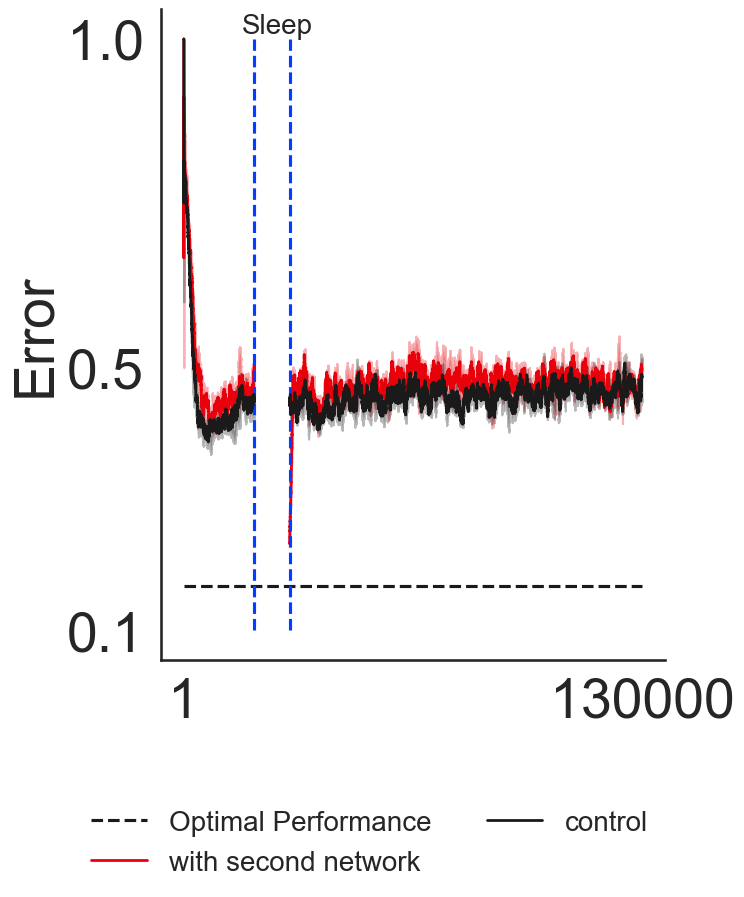

In [209]:
test_acc = np.array(test_acc)
test_acc_control = np.array(test_acc_control)
sleep_break = 10000
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.167, 0, total_samples+sleep_break, linestyles='dashed', label='Optimal Performance', color='k')

ax.plot(np.median(1-test_acc[:,:initial_training_sample],axis=0),linewidth=2, color='r', label='with second network')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc[:,:initial_training_sample], 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='r')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='r', alpha=.3)


# ax.plot(np.median(1-test_acc_not_sparse[:,:initial_training_sample],axis=0),linewidth=2, color='b', label='with cortex no sparsity')
# ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,:initial_training_sample], 0.75, axis=0), color='b', alpha=.3)

# ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.median(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:],axis=0),linewidth=2, color='b')
# ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_not_sparse[0][initial_training_sample+sleep_samples:])), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.25, axis=0), np.quantile(1-test_acc_not_sparse[:,initial_training_sample+sleep_samples:], 0.75, axis=0), color='b', alpha=.3)

ax.vlines(initial_training_sample, 0.1, 1, linestyles='dashed', color='b')
ax.vlines(initial_training_sample+sleep_break, 0.1, 1, linestyles='dashed', color='b')


ax.plot(np.median(1-test_acc_control[:,:initial_training_sample],axis=0),linewidth=2, color='k', label='control')
ax.fill_between(np.arange(1,initial_training_sample+1), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.25, axis=0), np.quantile(1-test_acc_control[:,:initial_training_sample], 0.75, axis=0), color='k', alpha=.3)

ax.plot(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.median(1-test_acc_control[:,initial_training_sample:],axis=0),linewidth=2, color='k')
ax.fill_between(np.arange(initial_training_sample+sleep_break,initial_training_sample+sleep_break+len(test_acc_control[0][initial_training_sample:])), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.25, axis=0), np.quantile(1-test_acc_control[:,initial_training_sample:], 0.75, axis=0), color='k', alpha=.3)


plt.xticks([1, total_samples+sleep_break])
plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.text(.34, .92, 'Sleep', rotation=0, fontsize=20)
fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()


# Test what the network is getting wrong

In [210]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, len(tokens))
        #self.fc2 = nn.Linear(len(tokens), len(tokens))
        
    def forward(self, x, h0=None, return_state_only = False):
        if h0 == None:
            out, h0 = self.rnn(x)
        else:   
            out, h0 = self.rnn(x, h0)
        #out = torch.nn.functional.relu(self.fc1(out[0]))
        # print(out.shape)

        if return_state_only:
            return out, h0
            
        out = self.fc1(out[:,-1,:])
        # out = torch.nn.functional.softmax(out, dim=2)
        return out, h0

In [181]:
### initial training ###
total_samples = 100000
working_memory = 8
reps = 5
test_acc_ = [[] for _ in range(reps)]
train_acc = [[] for _ in range(reps)]
hidden_size = 100
missclassified_test = [set() for _ in range(reps)]
missclassified_train = [set() for _ in range(reps)]
buffer_test = ['.']*8
buffer_train = ['.']*8

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    data_test = get_sequence(total_samples, 2, 3, train=False, random_state=rep)
    data_set_test = Dataset_converter(data_test, working_memory, short_term_memory)  
    data_set = Dataset_converter(data, working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    test_loader = DataLoader(data_set_test, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    correct_train = np.zeros(1000,dtype=float)
    
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):   
        
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y_, hidden = main_model(X)
        else:
            predicted_y_, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y_, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()

            buffer_train.pop(0)
            buffer_train.append(tokens[X.argmax(axis=2)[0][0]]) 
            
            buffer_test.pop(0)
            buffer_test.append(tokens[X_test.argmax(axis=2)[0][0]]) 
            
            if total == 0:
                predicted_y, hidden_ = main_model(X_test)
            else:
                predicted_y, hidden_ = main_model(X_test, hidden_)
                
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)


            true_y_train = y.argmax(axis=1)
            estimated_y_train = predicted_y_.argmax(axis=1)
            
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                if total >=30000:
                    missclassified_test[rep].add(tuple(buffer_test))
                correct[total%1000] = 0

            if true_y_train == estimated_y_train:
                    correct_train[total%1000] = 1
            else:
                if total >=30000:
                    missclassified_train[rep].add(tuple(buffer_train))
                correct_train[total%1000] = 0
                
            test_acc_[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            train_acc[rep].append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[rep][-1]:.4f}, test accuracy: {test_acc_[rep][-1]:.4f}')



Doing rep  0
Iter : 1001, loss: 1.1206, train accuracy: 0.5260, test accuracy: 0.4570
Iter : 2001, loss: 0.5973, train accuracy: 0.7000, test accuracy: 0.5730
Iter : 3001, loss: 0.2805, train accuracy: 0.7430, test accuracy: 0.6010
Iter : 4001, loss: 0.3629, train accuracy: 0.7380, test accuracy: 0.5880
Iter : 5001, loss: 0.1395, train accuracy: 0.7540, test accuracy: 0.6060
Iter : 6001, loss: 0.2541, train accuracy: 0.7420, test accuracy: 0.6160
Iter : 7001, loss: 0.0442, train accuracy: 0.7450, test accuracy: 0.5940
Iter : 8001, loss: 0.0391, train accuracy: 0.7500, test accuracy: 0.6120
Iter : 9001, loss: 0.2049, train accuracy: 0.7420, test accuracy: 0.5870
Iter : 10001, loss: 0.1075, train accuracy: 0.7460, test accuracy: 0.6160
Iter : 11001, loss: 0.0504, train accuracy: 0.7560, test accuracy: 0.5930
Iter : 12001, loss: 0.1135, train accuracy: 0.7640, test accuracy: 0.6070
Iter : 13001, loss: 0.0300, train accuracy: 0.7480, test accuracy: 0.6330
Iter : 14001, loss: 0.0467, train 

In [182]:
missclassified_train[0]

{('A', 'B', 'C', 'A', 'G', 'A', 'B', 'C'),
 ('A', 'B', 'C', 'A', 'G', 'A', 'C', 'B'),
 ('A', 'B', 'C', 'A', 'G', 'B', 'A', 'C'),
 ('A', 'B', 'C', 'A', 'G', 'B', 'C', 'A'),
 ('A', 'B', 'C', 'A', 'G', 'D', 'E', 'F'),
 ('A', 'B', 'C', 'A', 'G', 'D', 'F', 'E'),
 ('A', 'B', 'C', 'A', 'G', 'E', 'D', 'F'),
 ('A', 'B', 'C', 'A', 'G', 'E', 'F', 'D'),
 ('A', 'C', 'B', 'A', 'G', 'A', 'B', 'C'),
 ('A', 'C', 'B', 'A', 'G', 'A', 'C', 'B'),
 ('A', 'C', 'B', 'A', 'G', 'B', 'A', 'C'),
 ('A', 'C', 'B', 'A', 'G', 'B', 'C', 'A'),
 ('A', 'C', 'B', 'A', 'G', 'D', 'E', 'F'),
 ('A', 'C', 'B', 'A', 'G', 'D', 'F', 'E'),
 ('A', 'C', 'B', 'A', 'G', 'E', 'D', 'F'),
 ('A', 'C', 'B', 'A', 'G', 'E', 'F', 'D'),
 ('A', 'C', 'B', 'G', 'A', 'B', 'C', 'A'),
 ('A', 'C', 'B', 'G', 'A', 'C', 'B', 'A'),
 ('A', 'C', 'B', 'G', 'B', 'A', 'C', 'B'),
 ('A', 'C', 'B', 'G', 'B', 'C', 'A', 'B'),
 ('A', 'C', 'B', 'G', 'D', 'E', 'F', 'D'),
 ('A', 'C', 'B', 'G', 'D', 'F', 'E', 'D'),
 ('A', 'C', 'B', 'G', 'E', 'D', 'F', 'E'),
 ('A', 'C',

In [183]:
missclassified_test[0]

{('A', 'B', 'C', 'A', 'G', 'A', 'B', 'C'),
 ('A', 'B', 'C', 'A', 'G', 'A', 'C', 'B'),
 ('A', 'B', 'C', 'A', 'G', 'B', 'A', 'C'),
 ('A', 'B', 'C', 'A', 'G', 'B', 'C', 'A'),
 ('A', 'B', 'C', 'A', 'G', 'C', 'A', 'B'),
 ('A', 'B', 'C', 'A', 'G', 'C', 'B', 'A'),
 ('A', 'B', 'C', 'A', 'G', 'D', 'E', 'F'),
 ('A', 'B', 'C', 'A', 'G', 'D', 'F', 'E'),
 ('A', 'B', 'C', 'A', 'G', 'E', 'D', 'F'),
 ('A', 'B', 'C', 'A', 'G', 'E', 'F', 'D'),
 ('A', 'B', 'C', 'A', 'G', 'F', 'D', 'E'),
 ('A', 'B', 'C', 'A', 'G', 'F', 'E', 'D'),
 ('A', 'B', 'C', 'G', 'A', 'B', 'C', 'A'),
 ('A', 'B', 'C', 'G', 'A', 'C', 'B', 'A'),
 ('A', 'B', 'C', 'G', 'B', 'A', 'C', 'B'),
 ('A', 'B', 'C', 'G', 'B', 'C', 'A', 'B'),
 ('A', 'B', 'C', 'G', 'C', 'A', 'B', 'C'),
 ('A', 'B', 'C', 'G', 'C', 'B', 'A', 'C'),
 ('A', 'B', 'C', 'G', 'D', 'E', 'F', 'D'),
 ('A', 'B', 'C', 'G', 'D', 'F', 'E', 'D'),
 ('A', 'B', 'C', 'G', 'E', 'D', 'F', 'E'),
 ('A', 'B', 'C', 'G', 'E', 'F', 'D', 'E'),
 ('A', 'B', 'C', 'G', 'F', 'D', 'E', 'F'),
 ('A', 'B',

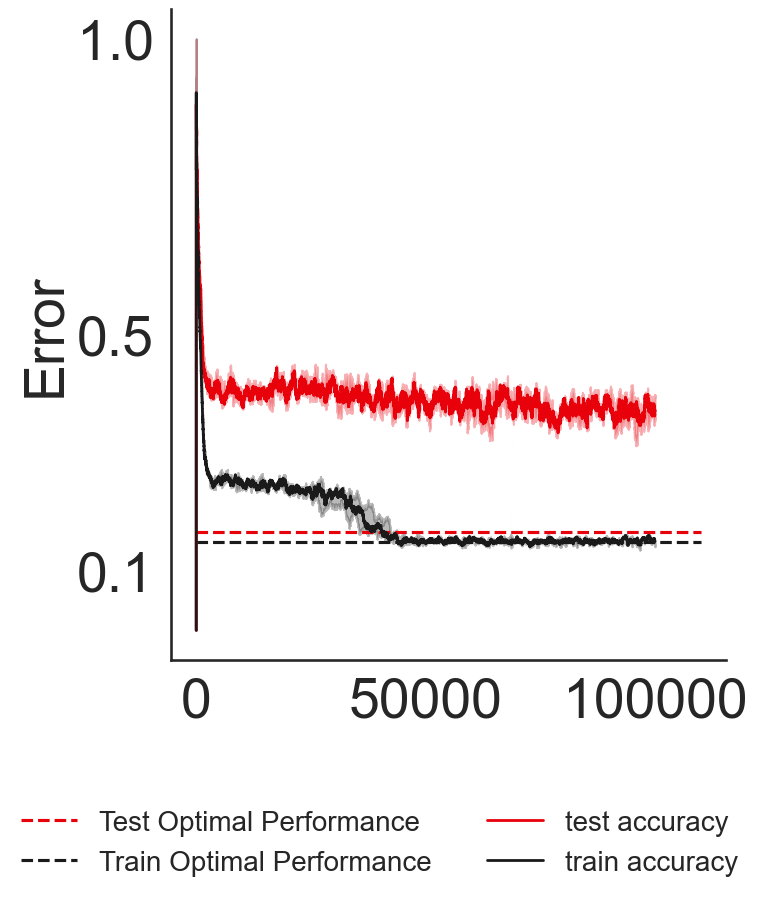

In [188]:
test_acc_ = np.array(test_acc_)
train_acc = np.array(train_acc)
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.167, 0, total_samples+sleep_break, linestyles='dashed', label='Test Optimal Performance', color='r')
ax.hlines(0.15, 0, total_samples+sleep_break, linestyles='dashed', label='Train Optimal Performance', color='k')

ax.plot(np.median(1-test_acc_,axis=0),linewidth=2, color='r', label='test accuracy')
ax.fill_between(np.arange(1,99992), np.quantile(1-test_acc_, 0.25, axis=0), np.quantile(1-test_acc_, 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.median(1-train_acc,axis=0),linewidth=2, color='k', label='train accuracy')
ax.fill_between(np.arange(1,99992), np.quantile(1-train_acc, 0.25, axis=0), np.quantile(1-train_acc, 0.75, axis=0), color='k', alpha=.3)


plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()


In [220]:
### initial training ###
total_samples = 100000
working_memory = 1
reps = 5
test_acc_ = [[] for _ in range(reps)]
train_acc = [[] for _ in range(reps)]
hidden_size = 100
missclassified_test = [set() for _ in range(reps)]
missclassified_train = [set() for _ in range(reps)]
buffer_test = ['.']*8
buffer_train = ['.']*8

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    data_test = get_sequence(total_samples, 2, 3, train=False, random_state=rep)
    data_set_test = Dataset_converter(data_test, working_memory, short_term_memory)  
    data_set = Dataset_converter(data, working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    test_loader = DataLoader(data_set_test, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    correct_train = np.zeros(1000,dtype=float)
    
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):   
        
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y_, hidden = main_model(X)
        else:
            predicted_y_, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y_, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()

            buffer_train.pop(0)
            buffer_train.append(tokens[X.argmax(axis=2)[0][0]]) 
            
            buffer_test.pop(0)
            buffer_test.append(tokens[X_test.argmax(axis=2)[0][0]]) 
            
            if total == 0:
                predicted_y, hidden_ = main_model(X_test)
            else:
                predicted_y, hidden_ = main_model(X_test, hidden_)
                
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)


            true_y_train = y.argmax(axis=1)
            estimated_y_train = predicted_y_.argmax(axis=1)
            
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                if total >=30000:
                    missclassified_test[rep].add(tuple(buffer_test))
                correct[total%1000] = 0

            if true_y_train == estimated_y_train:
                    correct_train[total%1000] = 1
            else:
                if total >=30000:
                    missclassified_train[rep].add(tuple(buffer_train))
                correct_train[total%1000] = 0
                
            test_acc_[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            train_acc[rep].append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[rep][-1]:.4f}, test accuracy: {test_acc_[rep][-1]:.4f}')



Doing rep  0
Iter : 1001, loss: 1.7028, train accuracy: 0.3510, test accuracy: 0.2840
Iter : 2001, loss: 0.7078, train accuracy: 0.6720, test accuracy: 0.5580
Iter : 3001, loss: 0.2786, train accuracy: 0.7430, test accuracy: 0.6060
Iter : 4001, loss: 0.4236, train accuracy: 0.7450, test accuracy: 0.5940
Iter : 5001, loss: 0.1625, train accuracy: 0.7560, test accuracy: 0.6050
Iter : 6001, loss: 0.2156, train accuracy: 0.7380, test accuracy: 0.6210
Iter : 7001, loss: 0.0467, train accuracy: 0.7350, test accuracy: 0.5970
Iter : 8001, loss: 0.0760, train accuracy: 0.7510, test accuracy: 0.6180
Iter : 9001, loss: 0.1464, train accuracy: 0.7450, test accuracy: 0.5780
Iter : 10001, loss: 0.0506, train accuracy: 0.7560, test accuracy: 0.6120
Iter : 11001, loss: 0.1146, train accuracy: 0.7660, test accuracy: 0.6190
Iter : 12001, loss: 0.0998, train accuracy: 0.7860, test accuracy: 0.6410
Iter : 13001, loss: 0.0388, train accuracy: 0.7930, test accuracy: 0.6170
Iter : 14001, loss: 0.0165, train 

KeyboardInterrupt: 

In [197]:
missclassified_train[0]

{('A', 'B', 'G', 'A', 'B', 'C', 'A', 'G'),
 ('A', 'B', 'G', 'A', 'C', 'B', 'A', 'G'),
 ('A', 'B', 'G', 'B', 'A', 'C', 'B', 'G'),
 ('A', 'B', 'G', 'B', 'C', 'A', 'B', 'G'),
 ('A', 'B', 'G', 'D', 'E', 'F', 'D', 'G'),
 ('A', 'B', 'G', 'D', 'F', 'E', 'D', 'G'),
 ('A', 'B', 'G', 'E', 'D', 'F', 'E', 'G'),
 ('A', 'B', 'G', 'E', 'F', 'D', 'E', 'G'),
 ('A', 'G', 'A', 'B', 'C', 'A', 'G', 'A'),
 ('A', 'G', 'A', 'B', 'C', 'A', 'G', 'B'),
 ('A', 'G', 'A', 'B', 'C', 'A', 'G', 'D'),
 ('A', 'G', 'A', 'B', 'C', 'A', 'G', 'E'),
 ('A', 'G', 'A', 'C', 'B', 'A', 'G', 'A'),
 ('A', 'G', 'A', 'C', 'B', 'A', 'G', 'B'),
 ('A', 'G', 'A', 'C', 'B', 'A', 'G', 'D'),
 ('A', 'G', 'A', 'C', 'B', 'A', 'G', 'E'),
 ('A', 'G', 'B', 'A', 'C', 'B', 'G', 'A'),
 ('A', 'G', 'B', 'A', 'C', 'B', 'G', 'B'),
 ('A', 'G', 'B', 'A', 'C', 'B', 'G', 'D'),
 ('A', 'G', 'B', 'A', 'C', 'B', 'G', 'E'),
 ('A', 'G', 'B', 'C', 'A', 'B', 'G', 'A'),
 ('A', 'G', 'B', 'C', 'A', 'B', 'G', 'B'),
 ('A', 'G', 'B', 'C', 'A', 'B', 'G', 'D'),
 ('A', 'G',

In [198]:
missclassified_test[0]

{('A', 'B', 'C', 'A', 'G', 'C', 'A', 'B'),
 ('A', 'B', 'C', 'A', 'G', 'C', 'B', 'A'),
 ('A', 'B', 'C', 'A', 'G', 'F', 'D', 'E'),
 ('A', 'B', 'C', 'A', 'G', 'F', 'E', 'D'),
 ('A', 'B', 'C', 'G', 'A', 'C', 'B', 'A'),
 ('A', 'B', 'C', 'G', 'B', 'A', 'C', 'B'),
 ('A', 'B', 'C', 'G', 'B', 'C', 'A', 'B'),
 ('A', 'B', 'C', 'G', 'C', 'A', 'B', 'C'),
 ('A', 'B', 'C', 'G', 'C', 'B', 'A', 'C'),
 ('A', 'B', 'C', 'G', 'D', 'F', 'E', 'D'),
 ('A', 'B', 'C', 'G', 'E', 'F', 'D', 'E'),
 ('A', 'B', 'C', 'G', 'F', 'D', 'E', 'F'),
 ('A', 'B', 'C', 'G', 'F', 'E', 'D', 'F'),
 ('A', 'B', 'G', 'A', 'B', 'C', 'A', 'G'),
 ('A', 'B', 'G', 'A', 'C', 'B', 'A', 'G'),
 ('A', 'B', 'G', 'B', 'A', 'C', 'B', 'G'),
 ('A', 'B', 'G', 'B', 'C', 'A', 'B', 'G'),
 ('A', 'B', 'G', 'C', 'A', 'B', 'C', 'G'),
 ('A', 'B', 'G', 'C', 'B', 'A', 'C', 'G'),
 ('A', 'B', 'G', 'D', 'E', 'F', 'D', 'G'),
 ('A', 'B', 'G', 'D', 'F', 'E', 'D', 'G'),
 ('A', 'B', 'G', 'E', 'D', 'F', 'E', 'G'),
 ('A', 'B', 'G', 'E', 'F', 'D', 'E', 'G'),
 ('A', 'B',

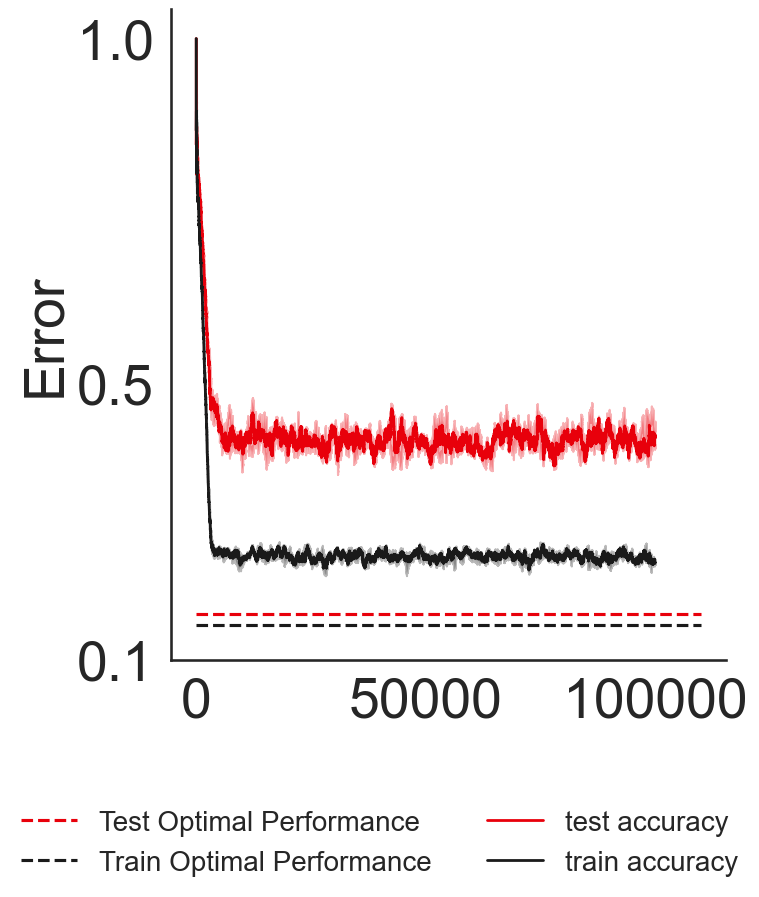

In [200]:
test_acc_ = np.array(test_acc_)
train_acc = np.array(train_acc)
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.167, 0, total_samples+sleep_break, linestyles='dashed', label='Test Optimal Performance', color='r')
ax.hlines(0.15, 0, total_samples+sleep_break, linestyles='dashed', label='Train Optimal Performance', color='k')

ax.plot(np.median(1-test_acc_,axis=0),linewidth=2, color='r', label='test accuracy')
ax.fill_between(np.arange(1,total_samples-1), np.quantile(1-test_acc_, 0.25, axis=0), np.quantile(1-test_acc_, 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.median(1-train_acc,axis=0),linewidth=2, color='k', label='train accuracy')
ax.fill_between(np.arange(1,total_samples-1), np.quantile(1-train_acc, 0.25, axis=0), np.quantile(1-train_acc, 0.75, axis=0), color='k', alpha=.3)


plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()


In [228]:
### initial training ###
total_samples = 200000
working_memory = 1
short_term_memory = 8
reps = 5
test_acc_ = [[] for _ in range(reps)]
train_acc = [[] for _ in range(reps)]
hidden_size = 200
missclassified_test = [set() for _ in range(reps)]
missclassified_train = [set() for _ in range(reps)]
buffer_test = ['.']*8
buffer_train = ['.']*8

for rep in range(reps):
    print('Doing rep ', rep)
    
    data = get_sequence(total_samples, 2, 3, train=False, random_state=rep)
    # data = pd.read_csv("../Seq_500000.txt")['seq'][0]
    data_test = get_sequence(total_samples, 2, 3, train=False, random_state=rep)
    data_set_test = Dataset_converter(data_test, working_memory, short_term_memory)  
    data_set = Dataset_converter(data, working_memory, short_term_memory)
    
    main_model = RNN(len(tokens)*working_memory, hidden_size, num_layers)
    
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
    test_loader = DataLoader(data_set_test, batch_size=1, shuffle=False) 
    
    optimizer = torch.optim.SGD(main_model.parameters(), lr=lr, momentum=0.95)
    criterion = torch.nn.CrossEntropyLoss()
    
    total = 0
    correct = np.zeros(1000,dtype=float)
    correct_train = np.zeros(1000,dtype=float)
    
    for (X, y), (X_test, y_test) in zip(train_loader, test_loader):   
        
        optimizer.zero_grad()
    
        if total == 0:
            predicted_y_, hidden = main_model(X)
        else:
            predicted_y_, hidden = main_model(X, mem)
            
        loss = criterion(predicted_y_, y)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            mem = hidden.clone()

            buffer_train.pop(0)
            buffer_train.append(tokens[X.argmax(axis=2)[0][0]]) 
            
            buffer_test.pop(0)
            buffer_test.append(tokens[X_test.argmax(axis=2)[0][0]]) 
            
            if total == 0:
                predicted_y, hidden_ = main_model(X_test)
            else:
                predicted_y, hidden_ = main_model(X_test, hidden_)
                
            true_y = y_test.argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=1)


            true_y_train = y.argmax(axis=1)
            estimated_y_train = predicted_y_.argmax(axis=1)
            
            total += 1
            if true_y == estimated_y:
                    correct[total%1000] = 1
            else:
                if total >=30000:
                    missclassified_test[rep].add(tuple(buffer_test))
                correct[total%1000] = 0

            if true_y_train == estimated_y_train:
                    correct_train[total%1000] = 1
            else:
                if total >=30000:
                    missclassified_train[rep].add(tuple(buffer_train))
                correct_train[total%1000] = 0
                
            test_acc_[rep].append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            train_acc[rep].append(
                np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
            )
            if total%1000 == 0:
                print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[rep][-1]:.4f}, test accuracy: {test_acc_[rep][-1]:.4f}')



Doing rep  0
Iter : 1001, loss: 1.3085, train accuracy: 0.2640, test accuracy: 0.2670
Iter : 2001, loss: 0.9016, train accuracy: 0.6220, test accuracy: 0.6370
Iter : 3001, loss: 0.5201, train accuracy: 0.7180, test accuracy: 0.7280
Iter : 4001, loss: 0.1980, train accuracy: 0.7380, test accuracy: 0.7440
Iter : 5001, loss: 0.2067, train accuracy: 0.7420, test accuracy: 0.7480
Iter : 6001, loss: 0.1136, train accuracy: 0.7410, test accuracy: 0.7470
Iter : 7001, loss: 0.1092, train accuracy: 0.7430, test accuracy: 0.7510
Iter : 8001, loss: 0.1850, train accuracy: 0.7400, test accuracy: 0.7460
Iter : 9001, loss: 0.2026, train accuracy: 0.7350, test accuracy: 0.7420
Iter : 10001, loss: 0.1346, train accuracy: 0.7480, test accuracy: 0.7550
Iter : 11001, loss: 0.0561, train accuracy: 0.7370, test accuracy: 0.7480
Iter : 12001, loss: 0.1704, train accuracy: 0.7400, test accuracy: 0.7480
Iter : 13001, loss: 0.1123, train accuracy: 0.7190, test accuracy: 0.7250
Iter : 14001, loss: 0.1600, train 

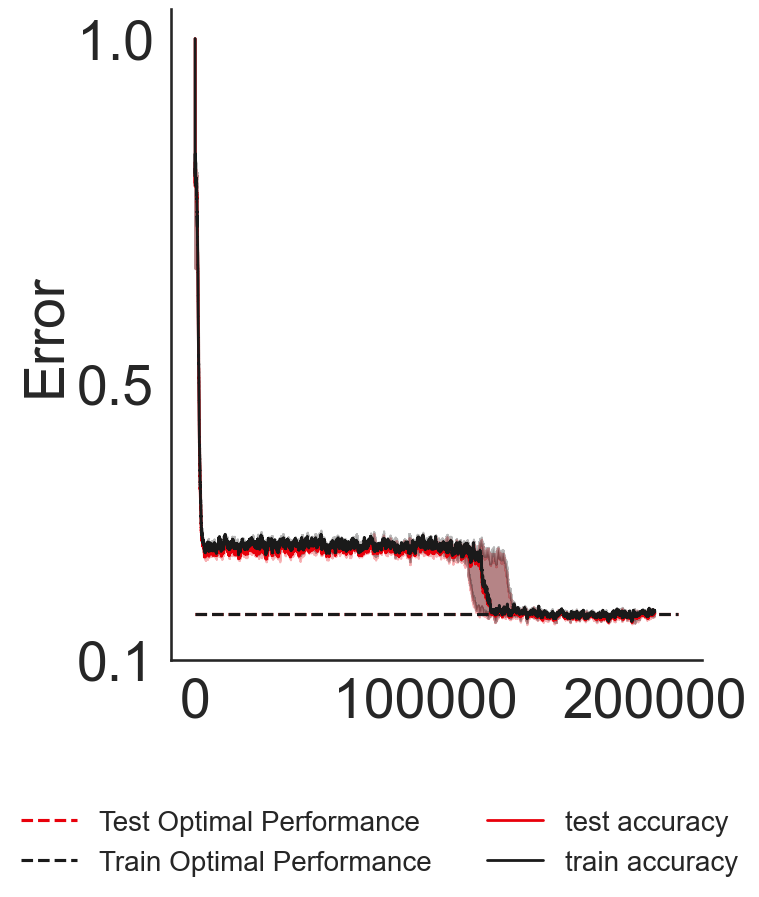

In [226]:
test_acc_ = np.array(test_acc_)
train_acc = np.array(train_acc)
sns.set(
        color_codes=True, palette="bright", style="white", context="talk", font_scale=1.5
    )
font = 40

fig, ax = plt.subplots(1, 1, figsize=(8,8), sharex=True, sharey=True)

ax.hlines(0.167, 0, total_samples+sleep_break, linestyles='dashed', label='Test Optimal Performance', color='r')
ax.hlines(0.167, 0, total_samples+sleep_break, linestyles='dashed', label='Train Optimal Performance', color='k')

ax.plot(np.median(1-test_acc_,axis=0),linewidth=2, color='r', label='test accuracy')
ax.fill_between(np.arange(1,199992), np.quantile(1-test_acc_, 0.25, axis=0), np.quantile(1-test_acc_, 0.75, axis=0), color='r', alpha=.3)

ax.plot(np.median(1-train_acc,axis=0),linewidth=2, color='k', label='train accuracy')
ax.fill_between(np.arange(1,199992), np.quantile(1-train_acc, 0.25, axis=0), np.quantile(1-train_acc, 0.75, axis=0), color='k', alpha=.3)


plt.yticks([0.1, 0.5, 1.0])

ax.set_ylabel('Error', fontsize=font)
# ax.set_yscale('log') 


ax.tick_params(labelsize=40)
    
right_side = ax.spines["right"]
right_side.set_visible(False)
top_side = ax.spines["top"]
top_side.set_visible(False)

fig.legend(bbox_to_anchor=(0.5, -0.02), bbox_transform=plt.gcf().transFigure,
                        ncol=2, loc='upper center', fontsize=20, frameon=False)
plt.tight_layout()
